# Projeto 1

Modelo de entrega da questão 2.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 2: Resolvendo sistemas tridiagonais.

### Questão 2.1
Escreva, em Python ou Julia, uma função `solve_tridiag(A, b)` que recebe uma matriz quadrada $A$ e um vetor $b$ e retorna a solução do sistema $Ax = b$ (você pode supor que $A$ é inversível).

In [649]:
import numpy as np
import timeit
import pandas as pd

In [650]:
def solve_tridiag(A, b):
    
    A_nrow = A.shape[0]
    
    L = np.identity(A_nrow)
    
    # Calculo das matrizes L e U
    for i in range(A_nrow-1):
        t = A[i+1,i] / A[i,i]
        A[i+1] = A[i+1] - t*A[i]
        L[i+1, i] = t
    
    # Calculo de y
    y = np.zeros(A_nrow)
    y[0] = b[0]
    for i in range(1, A_nrow):
        y[i] = b[i] - L[i,i-1]*y[i-1]
    
    #Calculo de x
    x = np.zeros(A_nrow)
    x[A_nrow-1] =  y[A_nrow-1]/A[A_nrow-1,A_nrow-1]
    for i in reversed(range(A_nrow-1)):
        x[i] = (y[i] - x[i+1]*A[i, i+1])/A[i,i]
        
    return x

### Questão 2.2
Verifique que sua função está correta, fazendo alguns testes.

In [651]:
A1 = np.array([
        [ 2.0, -1.0,  0.0],
        [-1.0,  2.0, -1.0],
        [ 0.0, -1.0,  2.0]
    ])
b1 = np.array([1.0, 0.0, 1.0])


print(solve_tridiag(A1.copy(),b1.copy()))
print(np.linalg.solve(A1.copy(), b1.copy()))



[1. 1. 1.]
[1. 1. 1.]


In [652]:
n2 = 5
A2 = np.diag(np.full(n2, 2.0)) + \
    np.diag(np.full(n2-1, -1.0), -1) + \
    np.diag(np.full(n2-1, -1.0), 1)
b2 = np.array([10.0, 20.0, 30.0, 40.0, 50.0])

print(solve_tridiag(A2.copy(),b2.copy()))
print(np.linalg.solve(A2.copy(), b2.copy()))

[ 58.33333333 106.66666667 135.         133.33333333  91.66666667]
[ 58.33333333 106.66666667 135.         133.33333333  91.66666667]


In [653]:
A3 = np.array([
        [10.0,  1.0,  0.0,  0.0],
        [ 2.0, 12.0,  3.0,  0.0],
        [ 0.0,  4.0, 15.0,  5.0],
        [ 0.0,  0.0,  6.0, 20.0]
    ])
b3 = np.array([5.0, -2.0, 8.0, 1.0])

print(solve_tridiag(A3.copy(),b3.copy()))
print(np.linalg.solve(A3.copy(), b3.copy()))

[ 0.54327902 -0.43279022  0.70230821 -0.16069246]
[ 0.54327902 -0.43279022  0.70230821 -0.16069246]


### Questão 2.3
Qual é a complexidade computacional da sua função?

### Questão 2.4
A partir de que tamanho de matriz $A$ a função `solve_tridiag` se torna mais rápida do que a função `numpy.linalg.solve` (ou `\`, em Julia)?
Como você fez para chegar neste resultado?

### Resposta

A função `solve_tridiag` se torna mais rápida que a do numpy a partir de uma matriz 75x75. Professor, minha ideia inicial era calcular a matriz inversa e depois apenas resolver o sistema linear multiplicando $x = A^{-1}b$, mas depois de procurar alguns conteúdos e assistir algumas aulas aprendi que calcular a inversa de uma matriz não é nada divertido para matrizes grandes porque nós teríamos um problema de complexidade computacional muito grande. Portanto, voltei ao material para tentar entender como eu poderia resolver o problema de forma mais eficaz. Procurei entender melhor como funciona a função `numpy.linalg.solve` e descobri que nossa principal vantagem com relação a ela é que ela não sabe que a matriz do sistema linear que ela está resolvendo é tridiagonal e nós, sim. Então, podemos fazer certas operações que não funcionariam para qulquer matriz. Em alguns conteúdos, Gilbert Strang aplica a fatoração A = LU para matrizes tridiagonais. Escolhido o método para resolver o problema passou a ser aplicar ele em python. Linha de raciocínio da função: 

1) Como nós temos uma matriz tridiagonal, quando fazemos a eliminação dos valores abaixo da diagonal principal, não preenchemos nenhuma entrada de zeros, ou seja, fazemos n-1 operações de eliminação para zerar as entradas abaixo dos pivôs. Calculamos a matriz L de forma que ela obedeça às seguintes condições: $0's$ acima da diagonal principal, diagonal pricipal de $1's$ e a facilidade da matriz tridiagonal, $n-1$ multiplicadores da eliminação alocados na diagonal imediatamente inferior à diagonal principal. A matriz resultante da nossa eliminação é a nossa U. Nosso problema passou a ser $LUx = b$ que eu dividi em duas etapas: 
2) $Ly = b$, sendo $b_0 = y_0$ porque a primeira linha de $L$ possui apenas 1 na primeira posição e $b_i = y_i + l_{i, i-1}*y_{i-1}$ para $i = 1, ...,n$
3) e depois $Ux = y$, sendo $x_n = y_n / u_{n, n}$ e $x_i = (y_i - x_{i+1})/u_{i, i}$ para $i = 1, ..., n-1$

Dessa forma, temos um for com $n-1$ fatores para calcular a $LU$, depois outro for com $n-1$ fatores calcular $y$ e depois um for com $n-1$ fatores para calcular $x$. 

<Axes: title={'center': 'Desempenho'}, xlabel='size'>

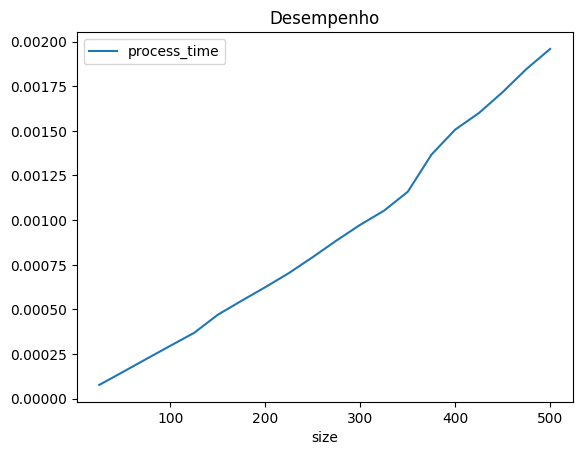

In [654]:
data_solve_tridiag = []

for n in range(25, 501, 25):

    A_rand = np.diag(np.random.rand(n)) + np.diag(np.random.rand(n-1), -1) + np.diag(np.random.rand(n-1), 1)
    b_rand = np.random.rand(n)

    tempos = timeit.repeat(lambda: solve_tridiag(A_rand, b_rand), number=10, repeat=5)
    tempo_estavel = min(tempos) / 10

    data_solve_tridiag.append({"size": n, "process_time": tempo_estavel})

df_solve_tridiag = pd.DataFrame(data_solve_tridiag)
df_solve_tridiag.plot(x="size", y="process_time", title="Desempenho")




<Axes: title={'center': 'Desempenho'}, xlabel='size'>

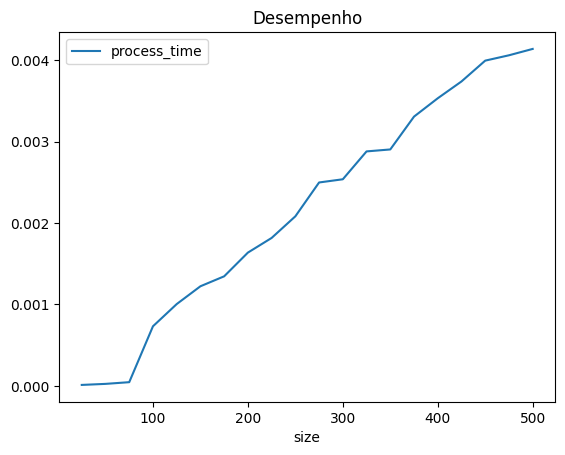

In [655]:
data_linalg_solve = []

for n in range(25, 501, 25):

    A_rand = np.diag(np.random.rand(n)) + np.diag(np.random.rand(n-1), -1) + np.diag(np.random.rand(n-1), 1)
    b_rand = np.random.rand(n)

    tempos = timeit.repeat(lambda: np.linalg.solve(A_rand, b_rand), number=10, repeat=5)
    tempo_estavel = min(tempos) / 10
    
    data_linalg_solve.append({"size": n, "process_time": tempo_estavel})

df_linalg_solve = pd.DataFrame(data_linalg_solve)
df_linalg_solve.plot(x="size", y="process_time", title="Desempenho")



<Axes: title={'center': 'Comparação de Desempenho'}, xlabel='size', ylabel='Tempo Total (s)'>

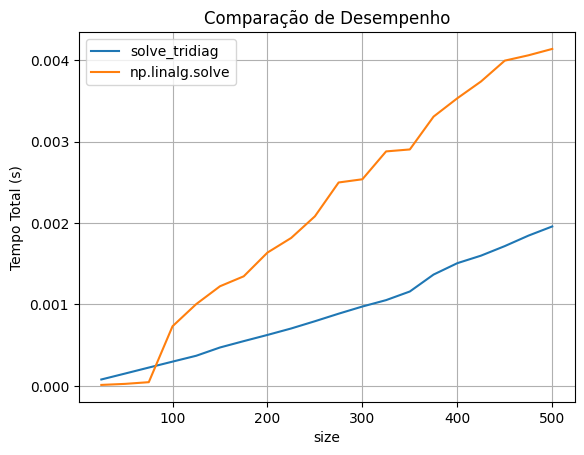

In [656]:
# Cria um novo DataFrame unindo os tempos
df_comparativo = pd.DataFrame({
    "size": df_solve_tridiag["size"],
    "solve_tridiag": df_solve_tridiag["process_time"],
    "np.linalg.solve": df_linalg_solve["process_time"]
})

# Plota as duas colunas juntas
df_comparativo.plot(x="size", y=["solve_tridiag", "np.linalg.solve"], 
                    title="Comparação de Desempenho",
                    ylabel="Tempo Total (s)",
                    grid=True)